> ### Fresh run (Cursor)
>
> 1. `cd PigeonPilot` then `pip install -e ".[dev]"` (once per venv)
> 2. If this file looks wrong: close tab **without saving**, reopen from disk
> 3. `Cmd + Shift + P` → **Jupyter: Restart Kernel and Run All Cells**


# PigeonPilot

**Research question:** Does STDP in a recurrent LIF reservoir improve path integration compared to a fixed reservoir?

Logic lives in `pigeonpilot/` (`paths` = domain, `curriculum` = dataset/schedule, `viz` = plots). This notebook only explains and runs it.

1. Displacement paths + curriculum  
2. Spike encoding — *next*  
3. Reservoir A vs B — *next*  
4. Readout — *next*


## 1. Displacement environment

Home = `(0, 0)`. A **level** = segments `(heading, distance)`.

### Two naming layers (do not mix them up)

**A) Trajectory family** = *shape* of the path (`linear` / `turning` / `curved`).  
Display labels come from `STYLE_LABELS` (printed below).

**B) Difficulty tag** = *curriculum stage* (`easy` / `medium` / `hard`).  
Full counts and skills come from `DIFFICULTY_SPECS` via `format_curriculum_table()` in §1.2.

- **Displacement vector:** home → release  
- **Home vector:** release → home


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from pigeonpilot.paths import (
    STYLES,
    DIFFICULTIES,
    generate_level,
)
from pigeonpilot.curriculum import (
    DEFAULT_EPOCHS_PER_DIFFICULTY,
    curriculum_level_count,
    format_curriculum_table,
    format_style_labels_table,
    generate_curriculum_dataset,
    split_dataset,
    summarize_dataset,
    iter_train_schedule,
)
from pigeonpilot.viz import (
    plot_level,
    plot_levels_grid,
    plot_release_points,
    compute_xy_limits,
)

print("imports ok")
print("trajectory families:", STYLES)
display(Markdown("### Trajectory family labels (`STYLE_LABELS`)"))
display(Markdown(format_style_labels_table()))


imports ok
trajectory families: ('linear', 'turning', 'curved')


### Trajectory family labels (`STYLE_LABELS`)

| Name | Meaning |
|------|---------|
| `linear` | straight / direct |
| `turning` | heading jumps (turns) |
| `curved` | wave or sweeping arc |

### 1.1 One example per trajectory family

`linear` / `turning` / `curved` — shared x/y scale.


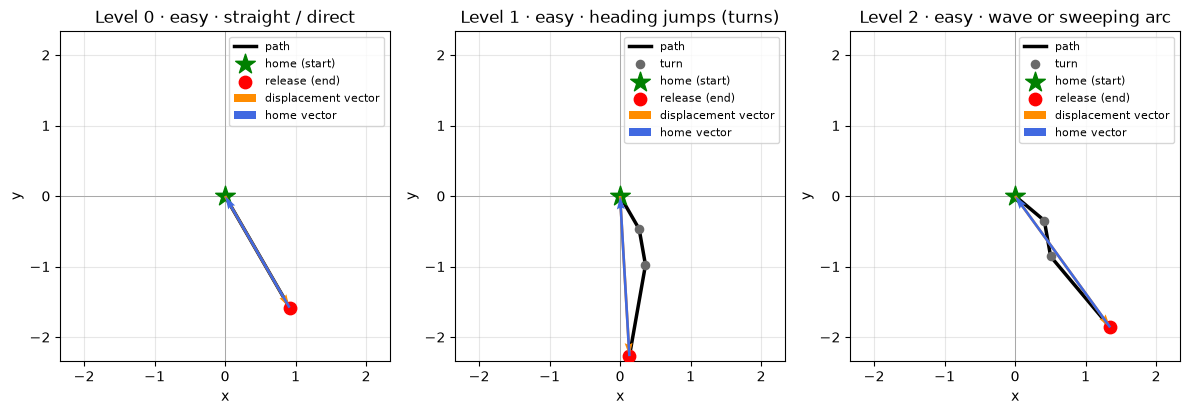

In [2]:
demo = [
    generate_level(style=s, n_segments=3, seed=0, level_id=i, turning_scale="gentle")
    for i, s in enumerate(("linear", "turning", "curved"))
]
xlim, ylim = compute_xy_limits(demo)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, level in zip(axes, demo):
    plot_level(level, ax=ax, xlim=xlim, ylim=ylim)
plt.tight_layout()
plt.show()


In [3]:
display(Markdown("### 1.2 Curriculum: difficulty tags × trajectory families"))
display(Markdown(format_curriculum_table()))
print("DEFAULT_EPOCHS_PER_DIFFICULTY:", DEFAULT_EPOCHS_PER_DIFFICULTY)


### 1.2 Curriculum: difficulty tags × trajectory families

| Difficulty | Count | Families used | Segments | Skill |
|------------|------:|---------------|----------|-------|
| **easy** | 60 | `linear` + gentle `turning` | 2–3 | distance + mild turn |
| **medium** | 60 | sharp `turning` + mild `curved` | 4–5 | many turns/curves (no linear) |
| **hard** | 30 | sharp `turning` + arc `curved` | 6–8 | long memory + circle-like arcs |

**Total = 150 levels.** Then ~80% train / ~20% test.

DEFAULT_EPOCHS_PER_DIFFICULTY: {'easy': 40, 'medium': 30, 'hard': 30}


### 1.3 Generate the full curriculum and plot them

Expected total comes from `curriculum_level_count()` (SSOT).

One figure per difficulty. Each grid zooms to that group only (square axes around home).


{'total': 150, 'by_difficulty': {'easy': 60, 'medium': 60, 'hard': 30}, 'by_style': {'linear': 30, 'turning': 75, 'curved': 45}}
train: 120 | test: 30


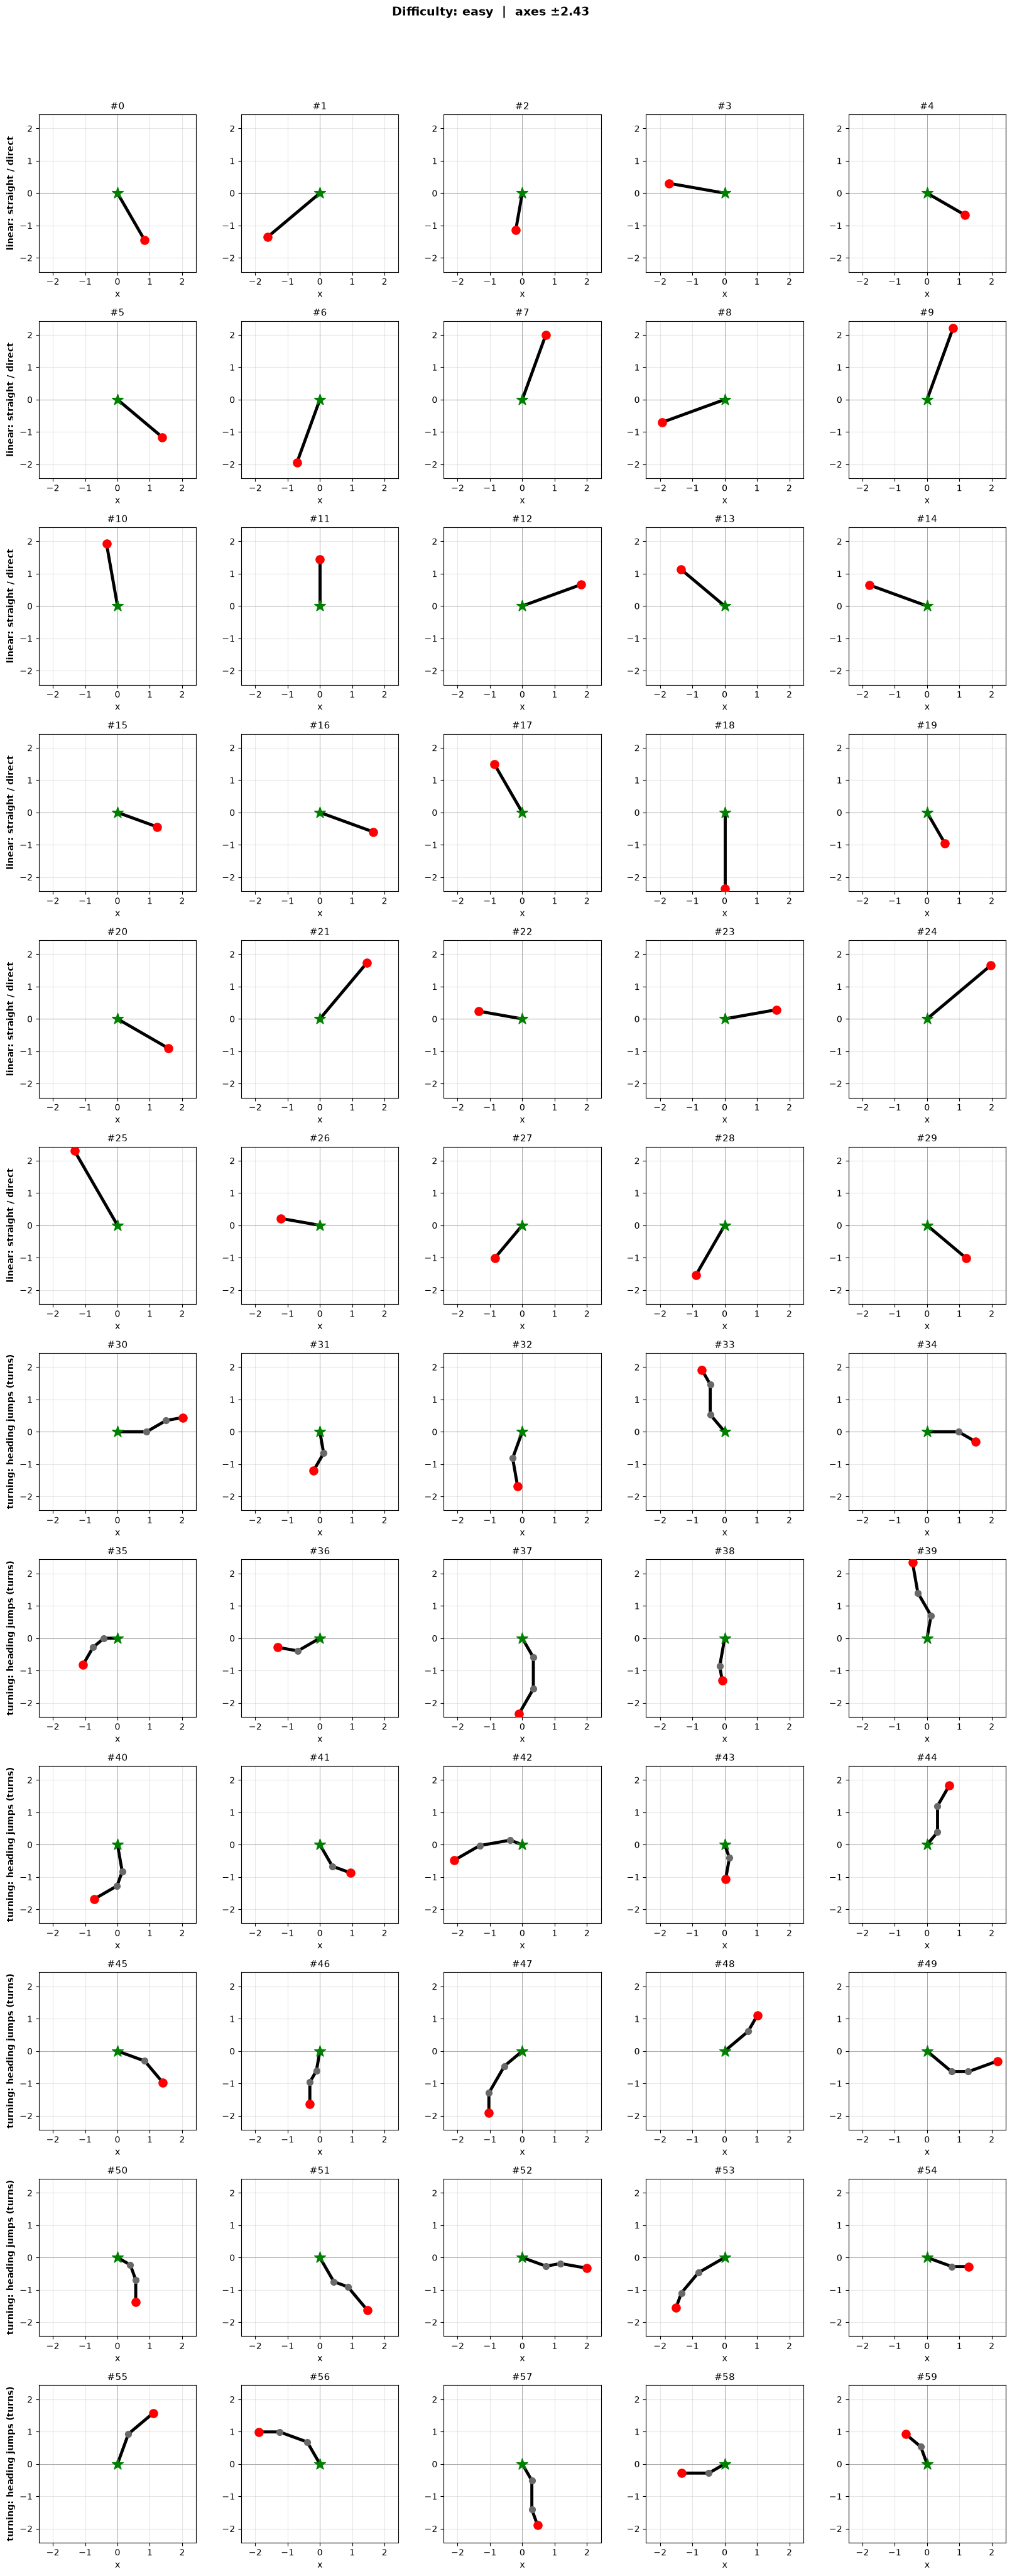

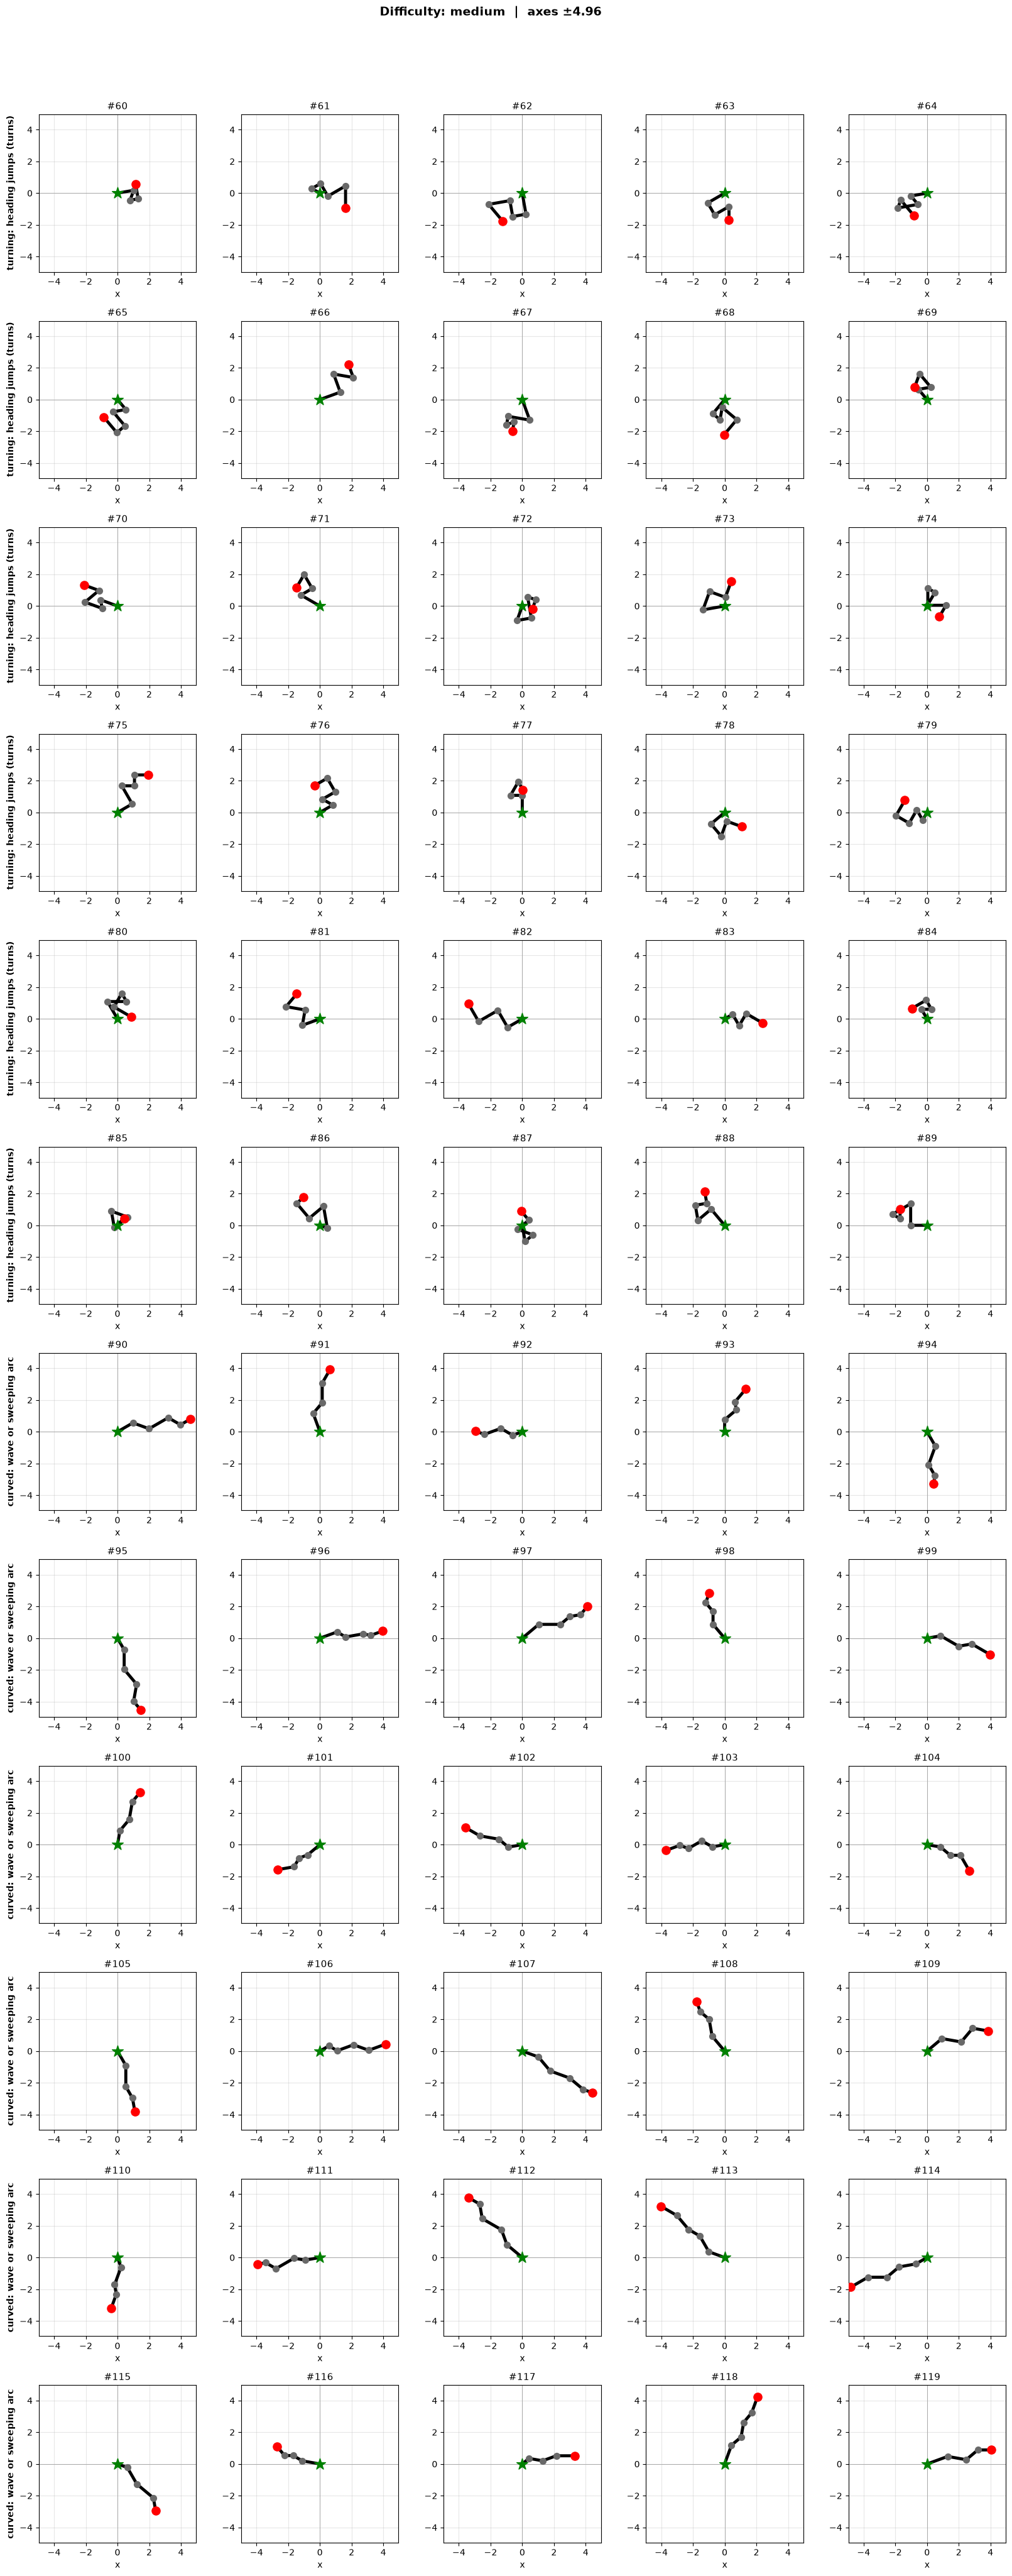

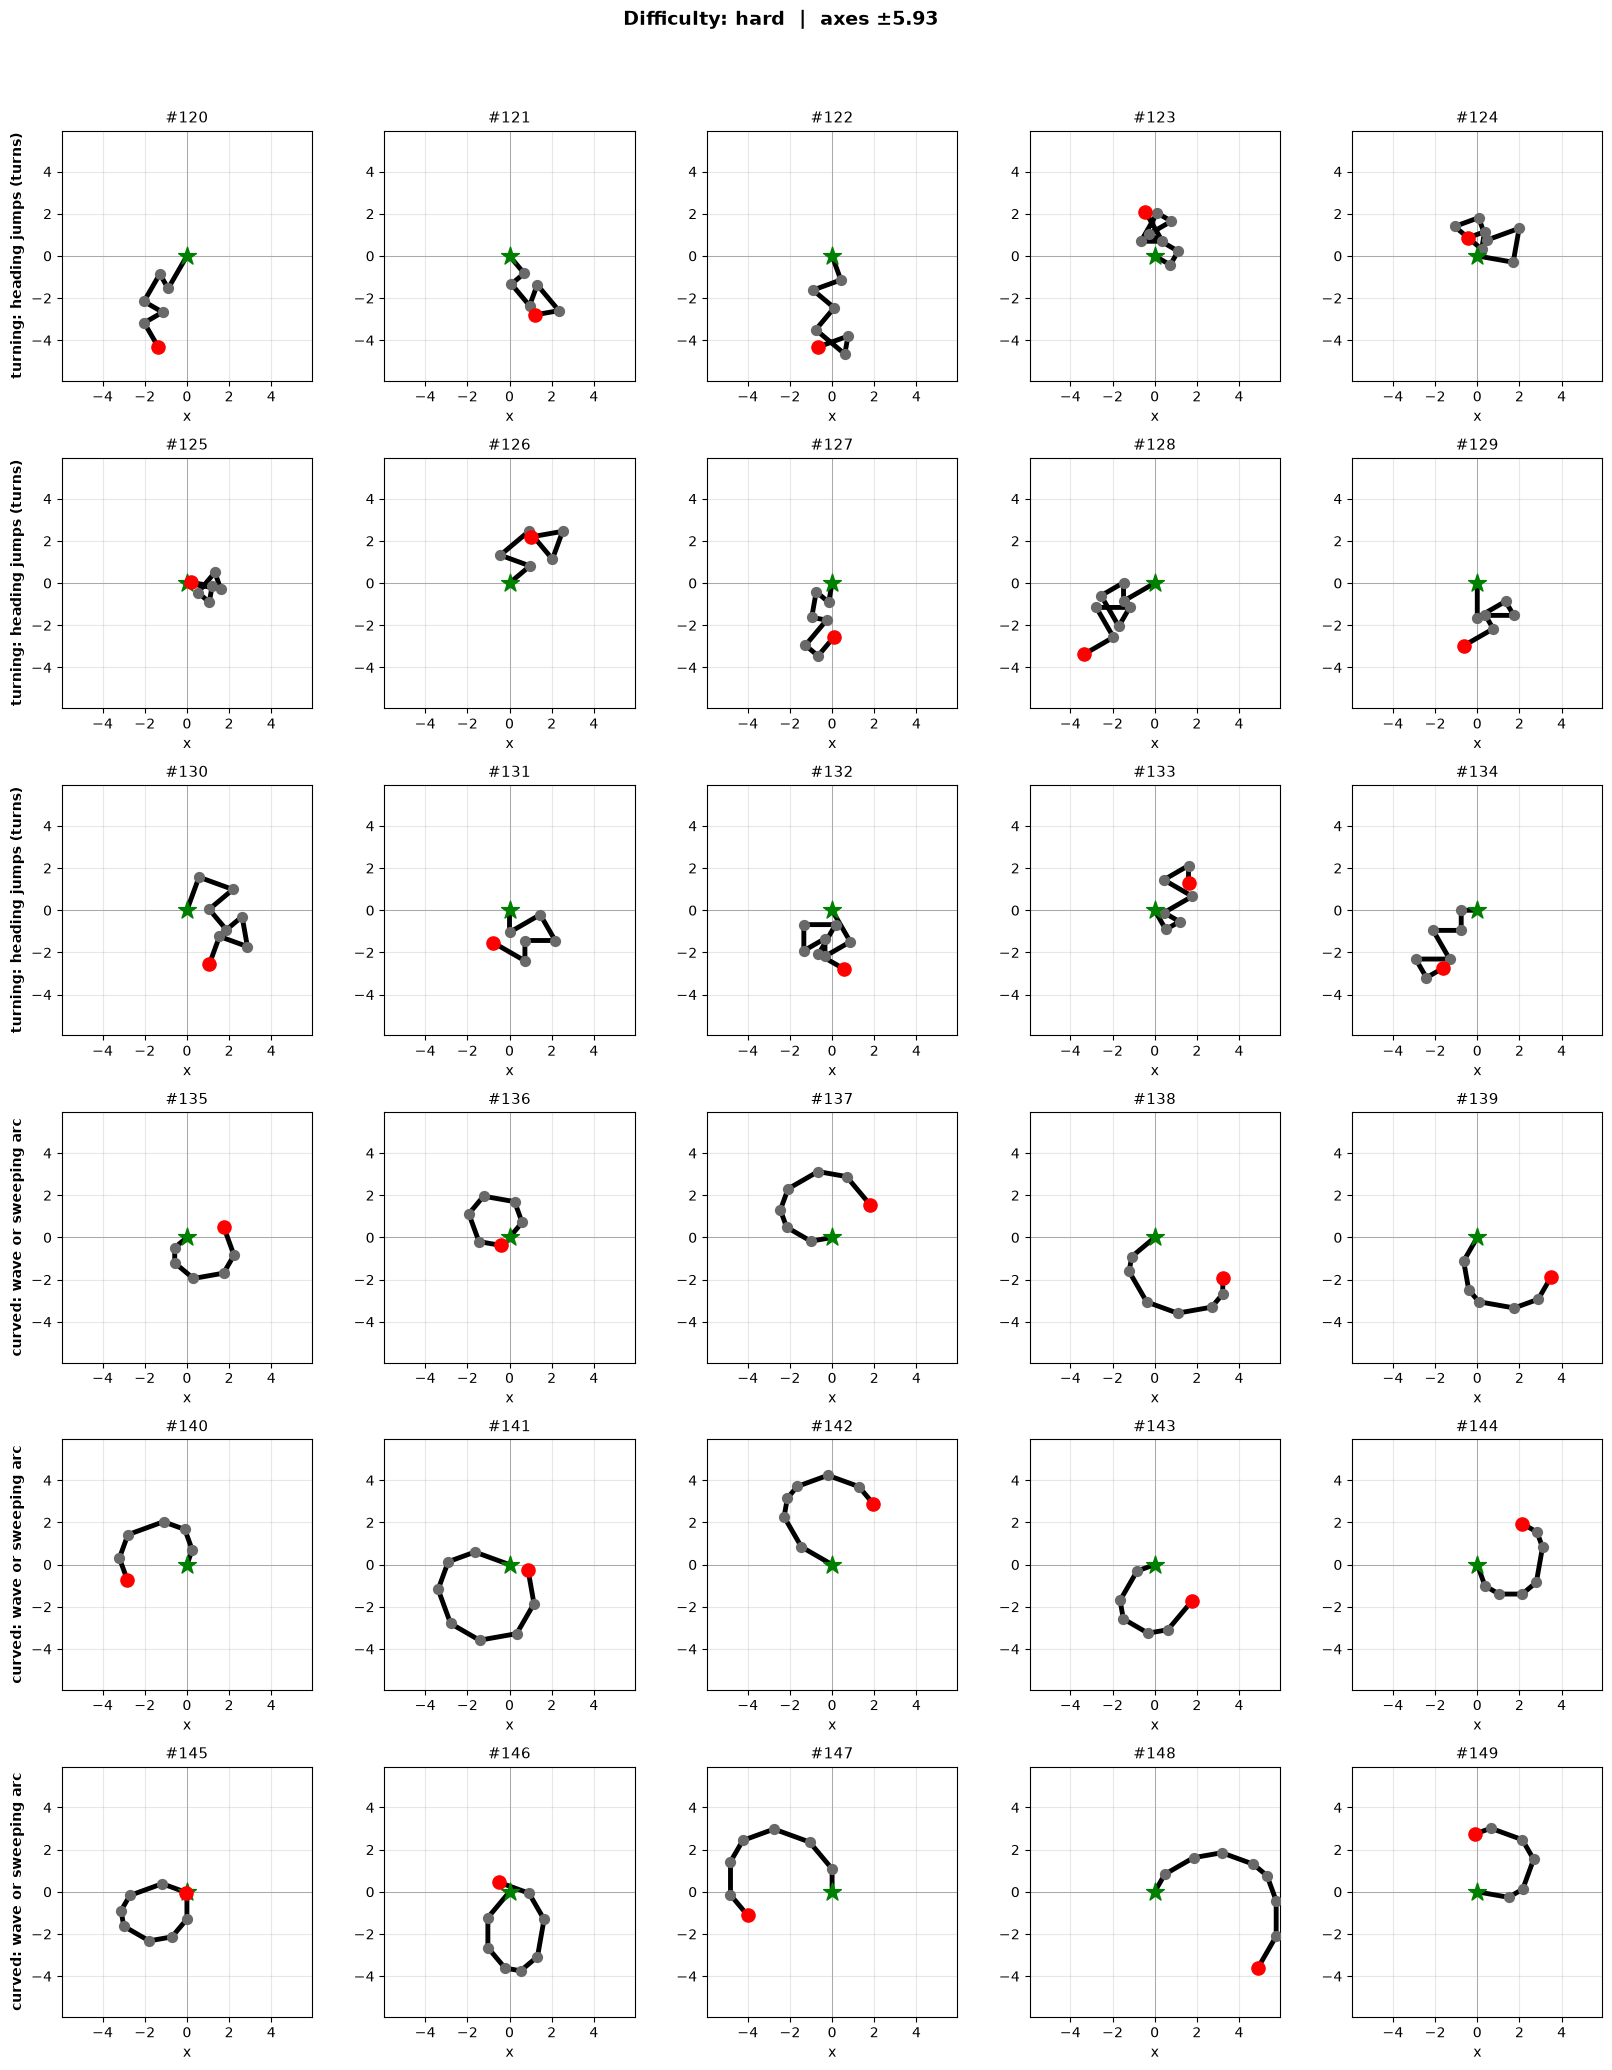

In [4]:
DATASET_SEED = 42
SPLIT_SEED = 0
EXPECTED_N = curriculum_level_count()

dataset = generate_curriculum_dataset(seed=DATASET_SEED)
print(summarize_dataset(dataset))
assert len(dataset) == EXPECTED_N, f"expected {EXPECTED_N}, got {len(dataset)}"

train_set, test_set = split_dataset(dataset, train_frac=0.8, seed=SPLIT_SEED)
print(f"train: {len(train_set)} | test: {len(test_set)}")

xlim_global, ylim_global = compute_xy_limits(dataset)

for difficulty in DIFFICULTIES:
    subset = [lv for lv in dataset if lv.difficulty == difficulty]
    plot_levels_grid(subset, title=f"Difficulty: {difficulty}")
    plt.show()


### 1.4 Training order

`SCHEDULE_MODE`:

- `"curriculum"` → **easy → medium → hard** (shuffle inside each difficulty)
- `"mixed"` → shuffle all train levels every epoch

Only `train_set` is used.


In [5]:
SCHEDULE_MODE = "curriculum"  # or "mixed"

schedule = list(
    iter_train_schedule(
        train_set,
        mode=SCHEDULE_MODE,
        epochs_per_difficulty=DEFAULT_EPOCHS_PER_DIFFICULTY,
        seed=0,
    )
)

from collections import Counter

print("mode:", SCHEDULE_MODE)
print("epochs_per_difficulty:", DEFAULT_EPOCHS_PER_DIFFICULTY)
print("presentations:", len(schedule))
print("per phase:", dict(Counter(phase for phase, *_ in schedule)))
print("first:", schedule[0][0], schedule[0][3].style, schedule[0][3].difficulty)
print("last:", schedule[-1][0], schedule[-1][3].style, schedule[-1][3].difficulty)


mode: curriculum
epochs_per_difficulty: {'easy': 40, 'medium': 30, 'hard': 30}
presentations: 4080
per phase: {'easy': 1920, 'medium': 1440, 'hard': 720}
first: easy linear easy
last: hard turning hard


### 1.5 Release-point map

Each dot = path end (release). Star = home. Color = difficulty.
Uses one global window so absolute distances stay comparable.


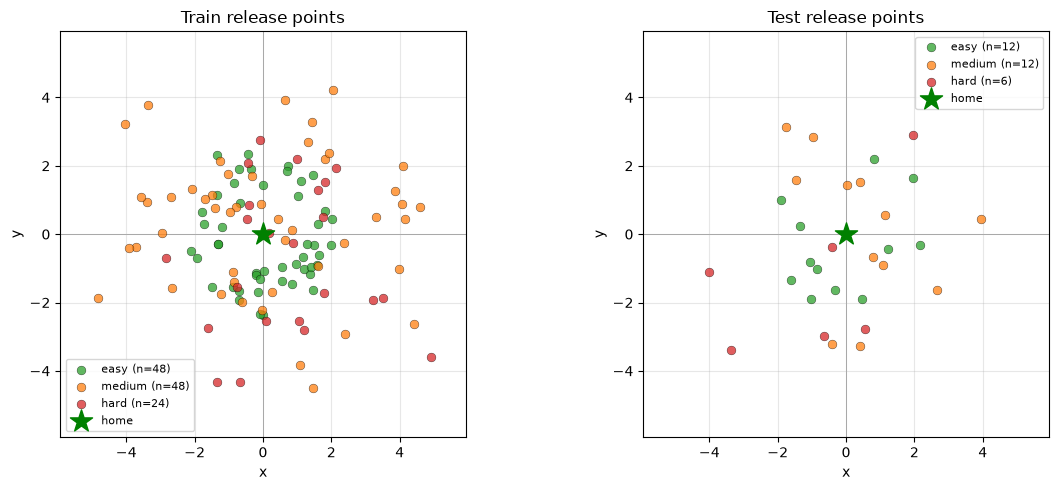

section 1 done | 150 levels | train 120 | test 30


In [6]:
# home_xy == -end_xy is locked in unit tests

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_release_points(
    train_set, ax=axes[0], title="Train release points",
    xlim=xlim_global, ylim=ylim_global,
)
plot_release_points(
    test_set, ax=axes[1], title="Test release points",
    xlim=xlim_global, ylim=ylim_global,
)
plt.tight_layout()
plt.show()

print(f"section 1 done | {len(dataset)} levels | train {len(train_set)} | test {len(test_set)}")


---

## 2. Spike encoding *(coming next)*

## 3. Reservoir A vs B *(coming next)*

## 4. Readout *(coming next)*
